In [1]:
import os
os.environ["CL_VERBOSE"]= "1"

Let's test the basic simulation elements, by running real langevin, where correct convergence is expected.  

In [2]:
# from complex_langevin.simulation.state import SimState
# from complex_langevin.simulation.evolution import SimEvol
# from complex_langevin.models.zero_d_scalar_phi4 import SimModel
# from complex_langevin.simulation.runner import SimRunner

# state1 = SimState(n_seeds = int(1e4), device="cpu", dt_base = 1e-3)
# model1 = SimModel(sigma=-1, lamb=1)
# evol1 = SimEvol(state1, model1)
# runner1 = SimRunner(state1, model1, evol1)


from complex_langevin.simulation.state import SimState
from complex_langevin.simulation.evolution import SimEvol
from complex_langevin.models.zero_d_scalar_phi4 import SimModel
from complex_langevin.simulation.runner import SimRunner
from complex_langevin.observables.observables import SimObs

import torch
import numpy as np
from tqdm import tqdm
from typing import List

def set_sim(
        sigma=1,
        lamb=1,
        n_seeds=int(1e4),
        device="cpu",
        dt_base=1e-3,
        ):
    
    state = SimState(n_seeds = n_seeds, device=device, dt_base = dt_base)
    model = SimModel(sigma=sigma, lamb = lamb)
    evol = SimEvol(state, model)
    runner = SimRunner(state, model, evol)
    return state, model, runner



In [3]:
def run_sim(state: SimState, model: SimModel, runner: SimRunner):
    for _ in tqdm(range(int(1e4))):
        runner.step()
        
    runner.log("Thermalization done!")
    
    for _ in tqdm(range(int(1e4))):
        runner.step()

    runner.log("Simulation done")

    return state, model, runner

In [4]:
sim_objects = set_sim(sigma = 1+1j)
state, model, runner = run_sim(*sim_objects)

1767054405.49386: [SimState] initialized
1767054405.49611: [scalar_phi4] initialized
1767054405.496174: [SimEvol] initialized
1767054405.496193: [SimRunner] initialized


  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:05<00:00, 1889.92it/s]


1767054410.8129869: [SimRunner] Thermalization done!


100%|██████████| 10000/10000 [00:05<00:00, 1864.13it/s]

1767054416.178234: [SimRunner] Simulation done


We can read off the prob. density of the process directly from state.phi.  
Because we know S(phi) analytically (see complex_langevin/models), we may compare this to exp(-S(phi))

In [5]:
def plot_hist(state: SimState, model: SimModel):
    import numpy as np
    import matplotlib.pyplot as plt

    nice_style =  {
                        'capsize':4,
                        'ls': 'none',
                        'elinewidth':2, 
                        'markersize':5,
                        'color': "red",
                        'marker': "o",
                    }
    # data
    data = state.phi.real.cpu().numpy()

    # histogram parameters
    bins = 50
    hist_range = (-4, 4)

    # raw histogram (counts)
    counts, edges = np.histogram(data, bins=bins, range=hist_range)
    centers = 0.5 * (edges[1:] + edges[:-1])
    bin_width = edges[1] - edges[0]

    # Poisson errors on counts
    count_err = np.sqrt(counts)

    # normalize to probability density
    N = len(data)
    density = counts / (N * bin_width)
    density_err = count_err / (N * bin_width)

    fig, axs = plt.subplots(1, figsize=(10, 5), sharey=True)

    # plot histogram with error bars
    axs.errorbar(
        centers,
        density,
        yerr=density_err,
        label="Langevin (MC)",
        **nice_style
    )

    # analytic curve
    x = np.linspace(-4, 4, 400)
    rho = np.exp(-model.action(x))
    rho /= model.partition_function()

    axs.plot(x, rho, lw=2, label="$e^{-S(\phi)} / Z$")

    axs.set_xlabel(r"$\phi$")
    axs.set_ylabel(r"$P(\phi)$")
    axs.legend()
    axs.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), fontsize = 20, loc="lower left",mode="expand", borderaxespad=0, ncol=4, handletextpad=1)


<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:49: SyntaxWarning: invalid escape sequence '\p'
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_65363/241690540.py:49: SyntaxWarning: invalid escape sequence '\p'
  axs.plot(x, rho, lw=2, label="$e^{-S(\phi)} / Z$")


1767054416.233248: [SimState] initialized
1767054416.2337348: [scalar_phi4] initialized
1767054416.233761: [SimEvol] initialized
1767054416.23377: [SimRunner] initialized


100%|██████████| 10000/10000 [00:05<00:00, 1871.08it/s]


1767054421.579272: [SimRunner] Thermalization done!


100%|██████████| 10000/10000 [00:05<00:00, 1889.21it/s]


1767054426.8731148: [SimRunner] Simulation done


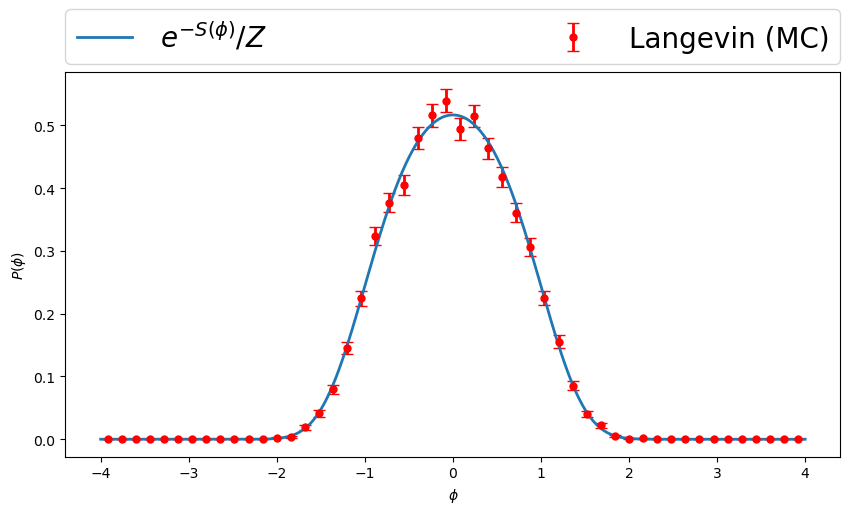

In [6]:
sim_objects = set_sim(sigma = 1)
state, model, runner = run_sim(*sim_objects)

plot_hist(state, model)

1767054427.164892: [SimState] initialized
1767054427.165327: [scalar_phi4] initialized
1767054427.1653602: [SimEvol] initialized
1767054427.165375: [SimRunner] initialized


100%|██████████| 10000/10000 [00:05<00:00, 1671.86it/s]


1767054433.1486452: [SimRunner] Thermalization done!


100%|██████████| 10000/10000 [00:05<00:00, 1892.16it/s]


1767054438.43427: [SimRunner] Simulation done


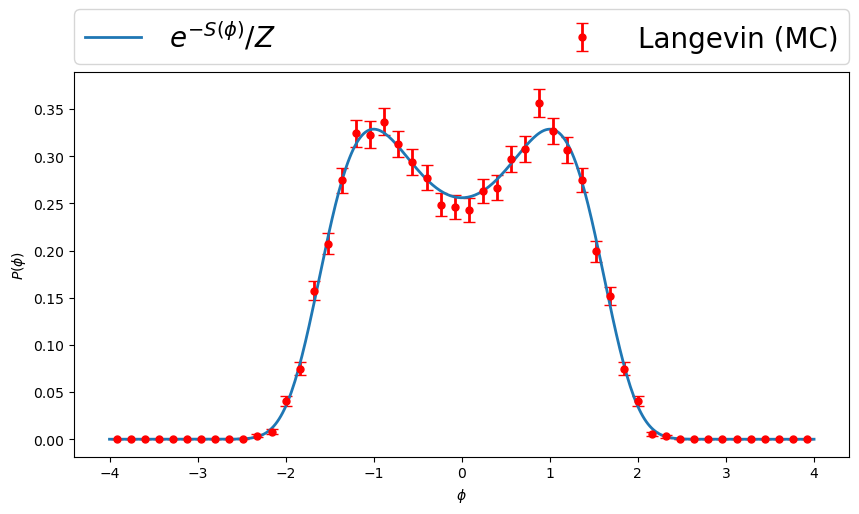

In [7]:
sim_objects = set_sim(sigma = -1)
state, model, runner = run_sim(*sim_objects)

plot_hist(state, model)